# HOMEWORK 8

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW8

In this homework you are going to implement your first machine learning algorithm to automatically binarize document images. The goal of document binarization is to seprate the characters (letters) from everything else. This is the crucial part for automatic document understanding and information extraction from the . In order to do so, you will use the Otsu thresholding algorithm.

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input images
# hm_version = 8
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone images
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

In [3]:
# Load data

import cv2
from pathlib import Path
import apps.reporter as rpt

# Input data
file_name = "resources/images/document.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

# Convert it to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# Convert image to gray scale
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")

images_dict = {
    "Original image": img_rgb,
    "Grayscale image": img_gray,
}


Attribute,Result
"(rows, cols, channels)","(882, 829, 3)"


Let's load the document image we will be working on in this homework.

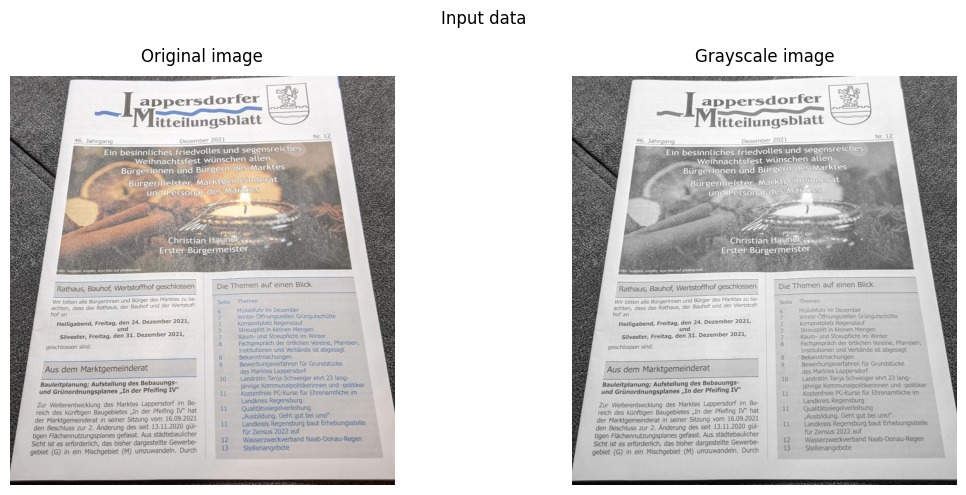

In [4]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 2
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Input data")
plt.tight_layout()
plt.show()


First, let's have a look at the histogram.

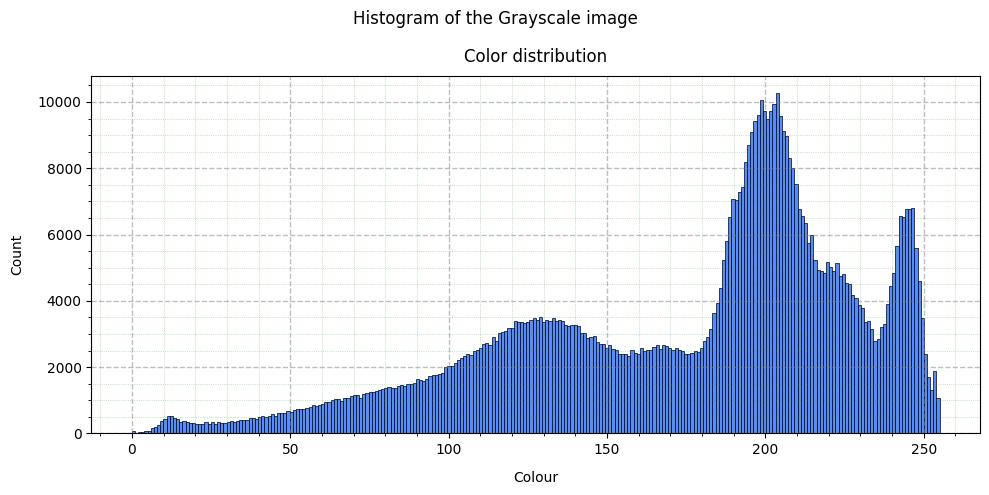

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_bins = 256
data = img_gray.flatten()

# Solution
_, ax = plt.subplots(figsize=(10, 5))

ax.hist(data, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Color distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Colour", labelpad=10, loc='center', color='black')
ax.set_ylabel("Count", labelpad=10, loc='center', color='black')

plt.suptitle("Histogram of the Grayscale image")

plt.tight_layout()
plt.show()

### Otsu Thresholding

Let's now implement the Otsu thresholding algorithm. Remember that the algorithm consists of an optimization process that finds the thresholds that minimizes the intra-class variance or, equivalently, maximizes the inter-class variance.

In this homework, you are going to demonstrate the working principle of the Otsu algorithm. Therefore, you won't have to worry about an efficient implementation, we are going to use the brute force approach here.

In [15]:
# Standard computing

import numpy as np
import apps.reporter as rpt

# Input data
# Initializations
best_wcv = np.finfo(np.float32).max  # Best within-class variance (wcv)
opt_th = None  # Threshold corresponding to the best wcv

# Get image dimensions
rows, cols = img_gray.shape

# Solution
gray_flat = img_gray.flatten()

# Compute the total amount of image pixels
num_pixels = rows * cols

# Brute force search using all possible thresholds (levels of gray)
for th in range(0, 256):
    # Extract the image pixels corresponding to the foreground
    foreground = gray_flat[gray_flat <= th]
    # Extract the image pixels corresponding to the background
    background = gray_flat[gray_flat > th]

    # If foreground or background are empty, continue
    if len(foreground) == 0 or len(background) == 0:
        continue

    # Compute class-weights (omega parameters) for foreground and background
    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels

    # Compute pixel variance for foreground and background
    # Hint: Check out the var function from numpy ;-)
    # https://numpy.org/doc/stable/reference/generated/numpy.var.html
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)

    # Compute the within-class variance
    wcv = omega_f * sigma2_f + omega_b * sigma2_b

    # Perform the optimization
    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th

# Form image according to the optimal threshold
img_th = img_gray > opt_th

rp = rpt.Reporter()
rp.add_item("Optimal threshold", str(opt_th))

# Print results
rp.print_pd_report("Computed")

images_dict["Image with optimal threshold"] = img_th


Attribute,Result
Optimal threshold,159


Finally, let's compare the original image and its thresholded representation.

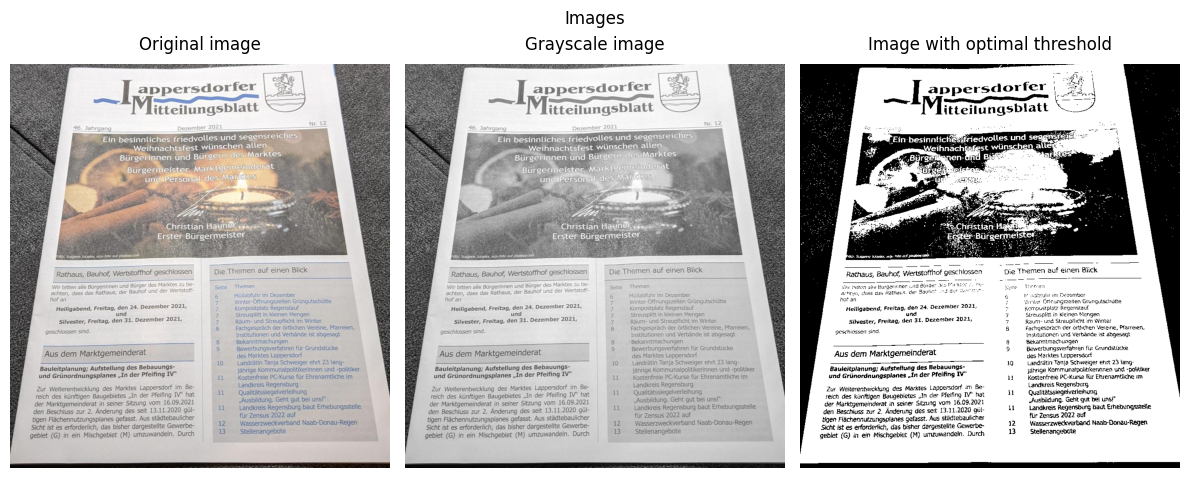

In [7]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 3
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Images")
plt.tight_layout()
plt.show()


In [18]:
# Faster computing

import numpy as np
import apps.reporter as rpt
from joblib import Parallel, delayed

# Input data
# Get image dimensions
rows, cols = img_gray.shape

# Solution
gray_flat = img_gray.flatten()
# Compute the total amount of image pixels
num_pixels = rows * cols


# Solution
def calc_opt_th_by_wcv(threshold: int, array: np.ndarray) -> tuple[int | None, float | None]:
    """
    Calculation of the optimal threshold by wcv (within-class variance)
    :param threshold: threshold level
    :param array: input data
    :return: list of tuples (threshold, wcv)
    """
    # Extract the image pixels corresponding to the foreground
    foreground = gray_flat[array <= threshold]
    # Extract the image pixels corresponding to the background
    background = gray_flat[array > threshold]

    # If foreground or background are empty, continue
    if len(foreground) == 0 or len(background) == 0:
        return None, None

    # Compute class-weights (omega parameters) for foreground and background
    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels

    # Compute pixel variance for foreground and background
    # Hint: Check out the var function from numpy ;-)
    # https://numpy.org/doc/stable/reference/generated/numpy.var.html
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)

    # Compute the within-class variance
    wcv = omega_f * sigma2_f + omega_b * sigma2_b

    return int(threshold), float(wcv)


# try to use multi-threading to accelerate speed
wcv_list = Parallel(n_jobs=-1)(
    delayed(calc_opt_th_by_wcv)(th, gray_flat)
    for th in range(0, 256)
)
# remove None
wcv_list = [(k, v) for (k, v) in wcv_list if (k is not None) and (v is not None)]
wcv_d = dict(wcv_list)

ths = np.asarray(list(wcv_d.keys()))
wcvs = np.asarray(list(wcv_d.values()))

# find optimal threshold
opt_id = np.argmin(wcvs)
opt_th2 = ths[opt_id]

rp = rpt.Reporter()
rp.add_item("Optimal threshold", str(opt_th))

# Print results
rp.print_pd_report("Computed by multi-threading")

Attribute,Result
Optimal threshold,159


### Questions

* Looking at the computed histogram, could it be considered bimodal?
* Looking at the computed histogram, what binarization threshold would you chose? Why?
* Looking at the resulting (thresholded) image, is the text binarization (detection) good?

### Answers
1. Looking at the shape of the histograms, it appears trimodal; a bimodal distribution has two peaks, whereas here at least three can be distinguished.
2. Visually, I would choose a threshold of around 180, because it appears to separate the two graph shapes, and the graph’s steepest slope begins at precisely that point.
3. When analyzing the resulting image, the binarization used for text detection is poor in some areas, as parts of the characters are lost, making recognition difficult.